In [1]:
import zipfile
import xarray as xr
import io
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [ ]:

def open_and_concat_nc_from_zip(zip_path, concat_dim="time"):
    """
    Abre um arquivo .zip contendo múltiplos NetCDF4
    e concatena todos em um único xarray.Dataset.
    """
    datasets = []

    with zipfile.ZipFile(zip_path, "r") as z:
        # pega apenas arquivos .nc
        nc_files = [f for f in z.namelist() if f.endswith(".zip")]
        nc_files.sort()  # garante ordem temporal

        for fname in nc_files:
            with z.open(fname) as f:
                data = f.read()
            file_like = io.BytesIO(data)

            # NetCDF4/HDF5 requer engine="h5netcdf"
            ds = xr.open_dataset(file_like, engine="h5netcdf")
            datasets.append(ds)

    combined = xr.concat(datasets, dim=concat_dim)
    return combined

In [4]:
data = './data_output/surface_downwelling_longwave_flux_2006.nc'

In [5]:
def open_and_concat_nc_from_zip(zip_path, concat_dim="time", ext=".nc"):
    """
    Abre um arquivo .zip contendo múltiplos NetCDF
    e concatena em um único xarray.Dataset.
    
    Parâmetros:
    -----------
    zip_path : str
        Caminho para o arquivo zipado.
    concat_dim : str
        Dimensão pela qual concatenar (default="time").
    ext : str
        Extensão alvo (default=".nc").
    """

    datasets = []

    with zipfile.ZipFile(zip_path, "r") as z:
        nc_files = sorted([f for f in z.namelist() if f.endswith(ext)])

        for fname in nc_files:
            try:
                with z.open(fname) as f:
                    file_like = io.BytesIO(f.read())
                    ds = xr.open_dataset(file_like, engine="h5netcdf")
                    datasets.append(ds)
            except Exception as e:
                print(f"[WARN] Falha ao abrir {fname}: {e}")

    if not datasets:
        raise ValueError("Nenhum dataset válido encontrado no zip.")

    # Ordena datasets por valor da coordenada 'time' se existir
    if concat_dim in datasets[0].coords:
        datasets.sort(key=lambda d: d[concat_dim].values[0])

    combined = xr.concat(datasets, dim=concat_dim)

    # Fecha datasets individuais para evitar warnings
    for ds in datasets:
        ds.close()

    return combined


In [7]:
ds = open_and_concat_nc_from_zip(data)

/tmp/ipykernel_15724/2316858065.py:37: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.concat(datasets, dim=concat_dim)


In [8]:
print(ds)

<xarray.Dataset> Size: 402kB
Dimensions:        (time: 12, bnds: 2, lon: 106, lat: 72)
Coordinates:
  * time           (time) datetime64[ns] 96B 2006-01-01 ... 2006-12-01
  * lon            (lon) float64 848B -56.38 -56.12 -55.88 ... -30.38 -30.12
  * lat            (lat) float64 576B -7.875 -7.625 -7.375 ... 9.375 9.625 9.875
Dimensions without coordinates: bnds
Data variables:
    time_bnds      (time, bnds) datetime64[ns] 192B 2006-01-01 ... 2007-01-01
    lon_bnds       (time, lon, bnds) float64 20kB -56.5 -56.25 ... -30.25 -30.0
    lat_bnds       (time, lat, bnds) float64 14kB -8.0 -7.75 -7.75 ... 9.75 10.0
    record_status  (time) int8 12B 0 0 0 0 0 0 0 0 0 0 0 0
    SDL            (time, lat, lon) float32 366kB 411.2 411.8 ... 403.4 403.2
Attributes: (12/41)
    source:                     AVHRR global area coverage (GAC)
    institution:                EUMETSAT/CMSAF
    Conventions:                CF-1.7,ACDD-1.3
    title:                      CM SAF Cloud, Albedo and Radia

In [9]:
sst = ds['SDL']
print(sst)

<xarray.DataArray 'SDL' (time: 12, lat: 72, lon: 106)> Size: 366kB
array([[[411.2321 , 411.81982, 412.97083, ..., 402.40805, 402.67767,
         402.98163],
        [412.78796, 412.80072, 413.43283, ..., 402.9408 , 403.11075,
         403.31174],
        [413.32523, 413.93332, 413.65237, ..., 403.42776, 403.47025,
         403.5356 ],
        ...,
        [412.16904, 412.1151 , 411.9942 , ..., 410.8094 , 410.85352,
         410.78488],
        [411.1869 , 411.07742, 410.91888, ..., 410.16553, 410.2881 ,
         410.27338],
        [410.2701 , 410.06747, 409.85666, ..., 409.40726, 409.46118,
         409.41382]],

       [[409.68622, 411.04752, 411.7425 , ..., 407.7306 , 407.6309 ,
         407.43808],
        [410.77756, 411.61063, 413.02112, ..., 407.87766, 407.88583,
         407.82864],
        [411.92233, 412.7997 , 412.6236 , ..., 407.88257, 407.93488,
         407.97897],
...
        [416.03503, 415.8687 , 415.62985, ..., 413.92416, 413.80978,
         413.6284 ],
        [415.9

In [10]:
sst[0]

<xarray.DataArray 'SDL' (lat: 72, lon: 106)> Size: 31kB
array([[411.2321 , 411.81982, 412.97083, ..., 402.40805, 402.67767,
        402.98163],
       [412.78796, 412.80072, 413.43283, ..., 402.9408 , 403.11075,
        403.31174],
       [413.32523, 413.93332, 413.65237, ..., 403.42776, 403.47025,
        403.5356 ],
       ...,
       [412.16904, 412.1151 , 411.9942 , ..., 410.8094 , 410.85352,
        410.78488],
       [411.1869 , 411.07742, 410.91888, ..., 410.16553, 410.2881 ,
        410.27338],
       [410.2701 , 410.06747, 409.85666, ..., 409.40726, 409.46118,
        409.41382]], shape=(72, 106), dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2006-01-01
  * lon      (lon) float64 848B -56.38 -56.12 -55.88 ... -30.62 -30.38 -30.12
  * lat      (lat) float64 576B -7.875 -7.625 -7.375 ... 9.375 9.625 9.875
Attributes:
    standard_name:  surface_downwelling_longwave_flux
    long_name:      Surface Downwelling Longwave Radiation
    units:          W/m2
    cell_methods:   area: time: mean

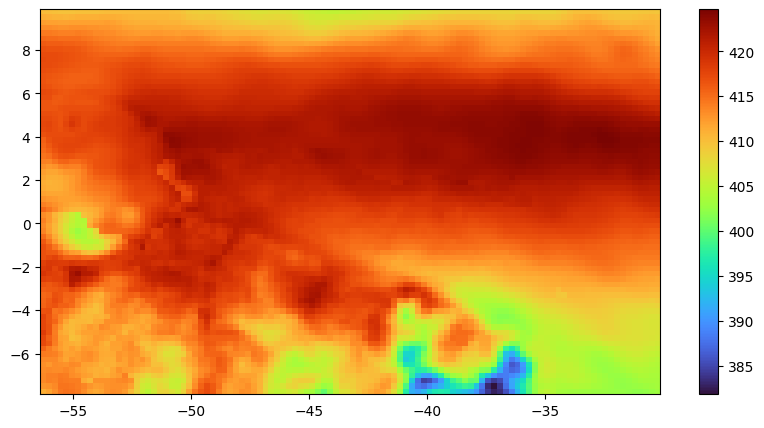

In [11]:
fig = plt.figure()
fig.set_size_inches(10,5)
plt.imshow(
    sst[0],
        origin="lower",
        cmap="turbo",
        extent=[
            float(sst.lon.min()),  # min lon
            float(sst.lon.max()),  # max lon
            float(sst.lat.min()),   # min lat
            float(sst.lat.max())    # max lat
        ],
        aspect="auto"
    )
plt.colorbar()

In [3]:
ds['time']

NameError: name 'ds' is not defined

NameError: name 'sst' is not defined

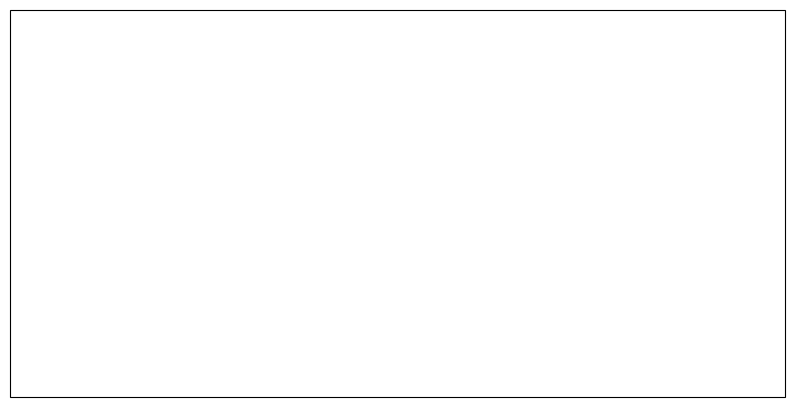

In [2]:
data_crs = ccrs.PlateCarree()
plot_crs = ccrs.PlateCarree() 

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=plot_crs)

extent = [
    float(sst.lon.min()),
    float(sst.lon.max()),
    float(sst.lat.min()),
    float(sst.lat.max())
]
ax.set_extent(extent, crs=data_crs)

Lons, Lats = np.meshgrid(sst.lon.values, sst.lat.values) 

sst_data = sst[0].values

min_val = 395
max_val = 430
n = 1

plot = ax.contourf(
    Lons, 
    Lats, 
    sst_data, 
    levels=np.arange(min_val, max_val, n),
    cmap="turbo",
    transform=data_crs
)

land_50m = cfeature.NaturalEarthFeature(
    'physical',
    'land',
    '50m',
    edgecolor='face',
    facecolor='lightgray' 
)

ax.add_feature(land_50m, zorder=2)
ax.coastlines(resolution='50m', color='black', linewidth=0.5, zorder=3)

plt.colorbar(plot, ax=ax, orientation='vertical', shrink=0.7)
ax.set_title(f'')

gl = ax.gridlines(crs=data_crs, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()